### Import libraries

In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.metrics import classification_report

In [2]:
# Load CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Limit training data to 10,000 samples
n = 10000

train_images = train_images[:n]
train_labels = train_labels[:n]

# Check shapes
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (10000, 32, 32, 3)
Train labels shape: (10000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


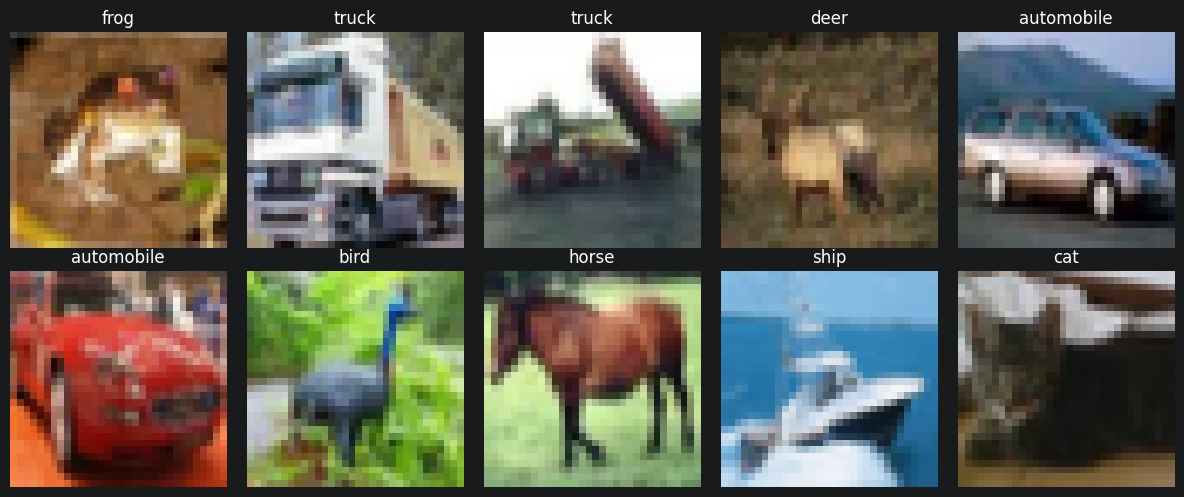

In [3]:
# CIFAR-10 class names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# Display first 10 images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

### prepare the images for Transfer Learning with ResNet50.

In [4]:
# Convert pixel values from 0-255 to 0-1

train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

print("Minimum pixel value:", train_images.min())
print("Maximum pixel value:", train_images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Build the ResNet50 base model

In [5]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# Freeze base model layers
base_model.trainable = False

base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

*** Build the custom classification head

In [6]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

*** Compile the model

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train the head (Phase 1)

In [8]:
history_head = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 101ms/step - accuracy: 0.1106 - loss: 2.3562 - val_accuracy: 0.1195 - val_loss: 2.2896
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.1175 - loss: 2.2729 - val_accuracy: 0.1610 - val_loss: 2.2524
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.1384 - loss: 2.2369 - val_accuracy: 0.1480 - val_loss: 2.2350
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.1399 - loss: 2.2195 - val_accuracy: 0.1975 - val_loss: 2.1482
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.1430 - loss: 2.2217 - val_accuracy: 0.1965 - val_loss: 2.1802
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.1406 - loss: 2.2240 - val_accuracy: 0.1855 - val_loss: 2.1755
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 90ms/step - accuracy: 0.1454 - loss: 2.2158 - val_accuracy: 0.2100 - val_loss: 2.1606
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.1416 - loss: 2.2145 -

### Phase 1: Training the Custom Head

In this phase, the ResNet50 base model was frozen and only the custom classification head was trained.

The validation accuracy stayed low, around 20%. This suggests that the frozen ImageNet features did not transfer very effectively to the small 32x32 CIFAR-10 images with the current preprocessing setup.

A likely limitation is that ResNet50 was originally trained on larger ImageNet images and expects specific preprocessing. Therefore, further improvement may require fine-tuning the base model and/or adjusting preprocessing.

### Phase 2 — unfreeze and fine-tune, but with a very small learning rate.

In [9]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Check trainable parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,169,056 (96.01 MB)

 Trainable params: 24,061,706 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 1,054,230 (4.02 MB)

In [10]:
# Recompile the model for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history_finetune = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 135s 450ms/step - accuracy: 0.1290 - loss: 3.9572 - val_accuracy: 0.1130 - val_loss: 81.1670
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 310ms/step - accuracy: 0.1641 - loss: 3.1839 - val_accuracy: 0.1035 - val_loss: 148.9224
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - accuracy: 0.2085 - loss: 2.7873 - val_accuracy: 0.1050 - val_loss: 7.0583
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 92s 370ms/step - accuracy: 0.2375 - loss: 2.4963 - val_accuracy: 0.2455 - val_loss: 2.3017
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 86s 345ms/step - accuracy: 0.2691 - loss: 2.3219 - val_accuracy: 0.3295 - val_loss: 2.0548
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 421ms/step - accuracy: 0.3090 - loss: 2.1294 - val_accuracy: 0.3585 - val_loss: 1.9736
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 340ms/step - accuracy: 0.3467 - loss: 1.9809 - val_accuracy: 0.3800 - val_loss: 1.8850
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 86s 343ms/step - accuracy: 0.3658 - lo

### Evaluate on the test set

In [12]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.4439 - loss: 1.6701

Test Loss: 1.6701
Test Accuracy: 0.4439


### Make predictions

In [13]:
# Predict classes for the test images
predictions = model.predict(test_images)

# Convert probabilities to class indices
predicted_labels = np.argmax(predictions, axis=1)

# Convert test labels to 1D
true_labels = test_labels.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step


### Display predictions

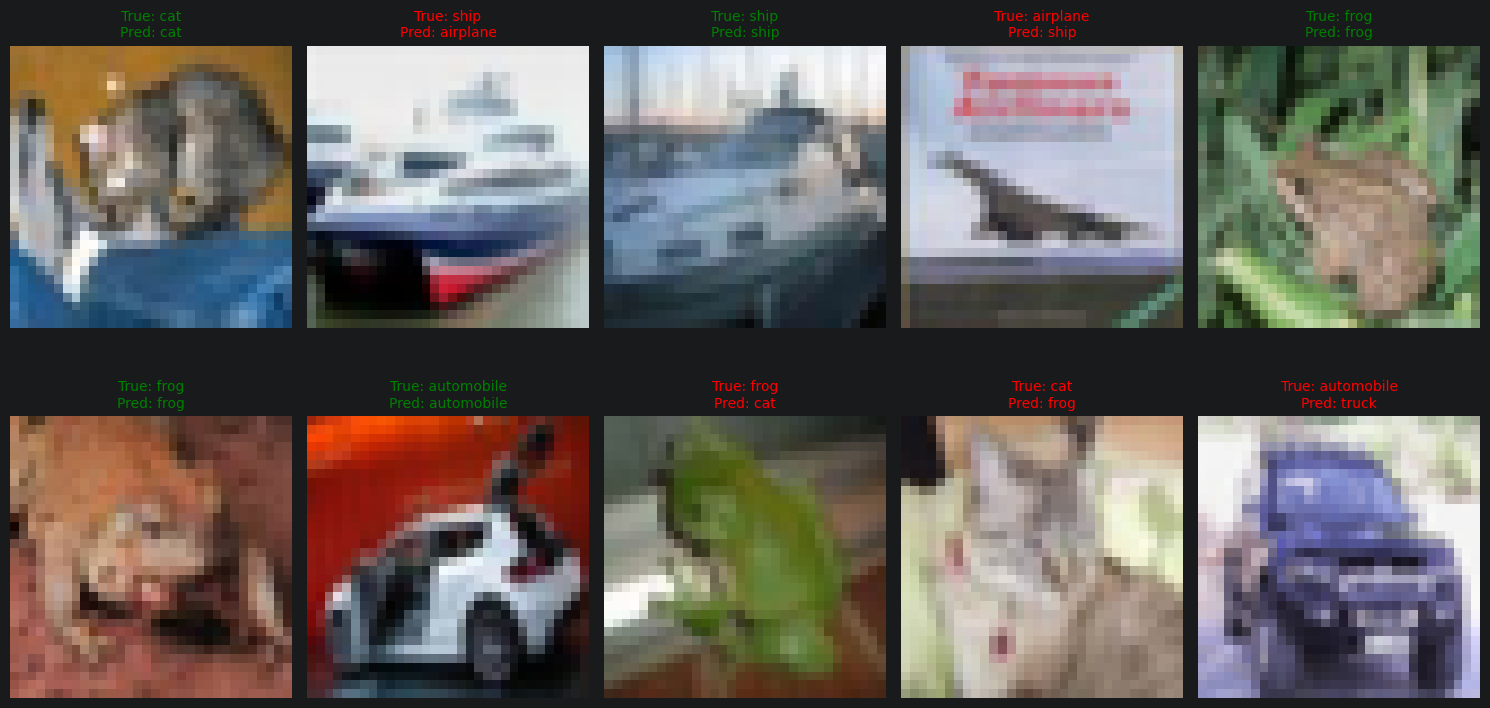

In [14]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i])

    color = "green" if predicted_labels[i] == true_labels[i] else "red"

    plt.title(
        f"True: {class_names[true_labels[i]]}\n"
        f"Pred: {class_names[predicted_labels[i]]}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### Plot the training history

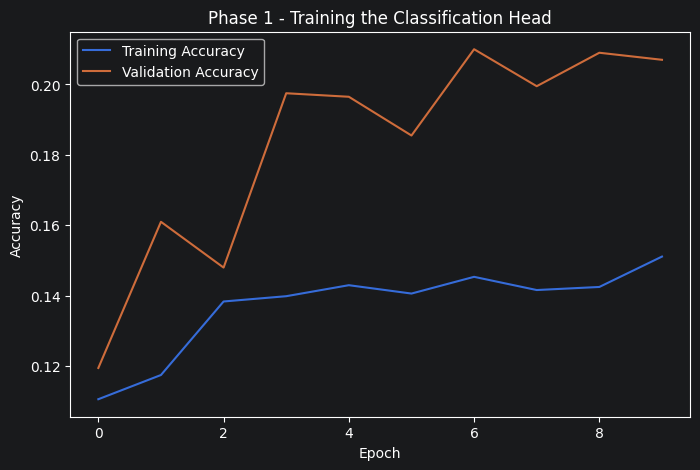

In [15]:
## Phase 1 - Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_head.history['accuracy'], label='Training Accuracy')
plt.plot(history_head.history['val_accuracy'], label='Validation Accuracy')

plt.title('Phase 1 - Training the Classification Head')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

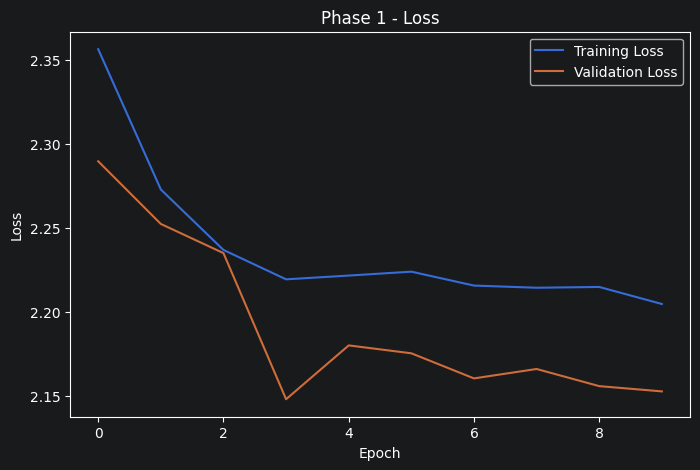

In [16]:
## Phase 1 Loss

plt.figure(figsize=(8, 5))

plt.plot(history_head.history['loss'], label='Training Loss')
plt.plot(history_head.history['val_loss'], label='Validation Loss')

plt.title('Phase 1 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

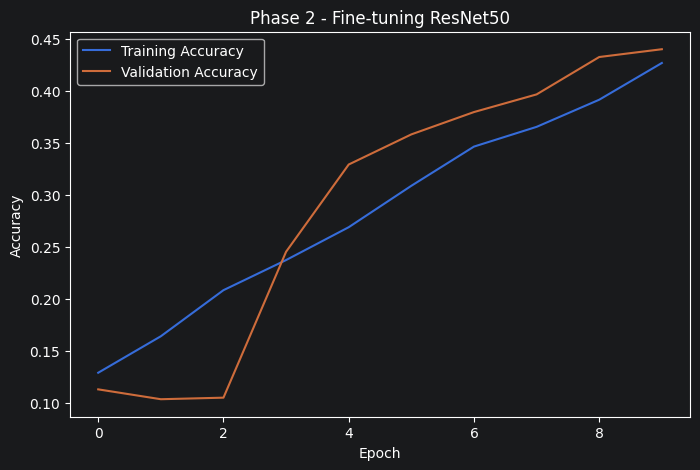

In [17]:
## Phase 2 Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')

plt.title('Phase 2 - Fine-tuning ResNet50')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

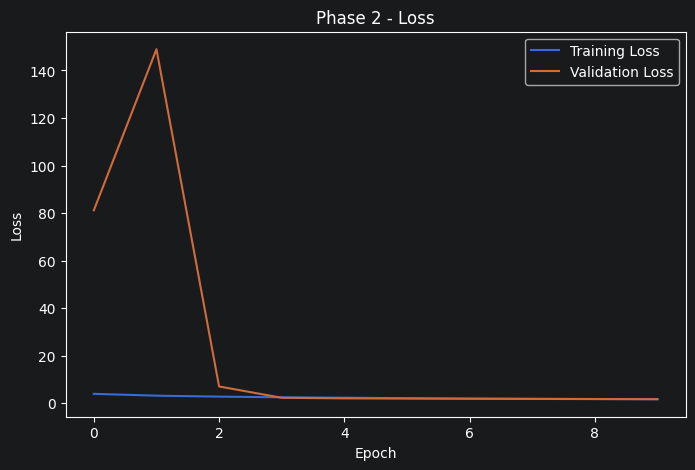

In [18]:
## Phase 2 Loss

plt.figure(figsize=(8, 5))

plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')

plt.title('Phase 2 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Final Conclusion

# Conclusion

In this project, I built an image classification model using transfer learning with ResNet50 on the CIFAR-10 dataset.

The project started with loading and preprocessing the dataset, followed by building a custom classification head on top of a pretrained ResNet50 model.

During Phase 1, only the custom head was trained while the pretrained ResNet50 layers remained frozen. The model achieved approximately 20% validation accuracy, indicating that the pretrained ImageNet features alone were not sufficient for this task.

During Phase 2, the ResNet50 base model was unfrozen and fine-tuned using a much smaller learning rate. This significantly improved the validation accuracy to approximately 45% and the final test accuracy to 44.39%.

Although the final accuracy is moderate, the project successfully demonstrates the complete transfer learning workflow, including preprocessing, model building, freezing and fine-tuning, evaluation, and prediction analysis. The relatively low image resolution (32×32 pixels), limited training dataset (10,000 images), and short training time contributed to the remaining classification errors.